# Week 2: Exploratory Data Analysis and Visualization

## Telco Customer Churn Dataset

### Objective

The objective of Week 2 is to perform Exploratory Data Analysis (EDA) on the
Telco Customer Churn dataset. The analysis focuses on understanding the
dataset structure, distributions, customer characteristics, churn patterns,
outliers, feature relationships, and important variables that may influence
customer churn.

The analysis uses statistical summaries and visualizations to identify
patterns and generate insights that can support further machine learning
analysis.

In [4]:
# Week 2: Exploratory Data Analysis and Visualization
# Telco Customer Churn Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
df = pd.read_csv('/content/Telco-Customer-Churn.csv')

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (7043, 21)


### Observation

The dataset contains 7,043 customer records and 21 columns. The dataset
contains demographic information, subscribed services, account information,
billing details, and the customer churn outcome.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [8]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical Features:")
print(list(numeric_columns))

print("\nCategorical Features:")
print(list(categorical_columns))

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical Features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [9]:
missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values[missing_values > 0])

Missing values by column:
Series([], dtype: int64)


In [10]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [11]:
duplicate_count = df.duplicated().sum()

print("Number of exact duplicate rows:", duplicate_count)

Number of exact duplicate rows: 0


In [12]:
unique_counts = df.nunique().sort_values()

print("Number of unique values per column:")
print(unique_counts)

Number of unique values per column:
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64


### Dataset Characteristics

The dataset contains 7,043 customer records and 21 features. The unique-value
analysis shows that several variables are binary, including gender,
SeniorCitizen, Partner, Dependents, PhoneService, PaperlessBilling, and Churn.
Several service-related variables contain three categories, while
PaymentMethod contains four distinct categories.

The numerical variable tenure contains 73 unique values, while MonthlyCharges
and TotalCharges contain 1,585 and 6,531 unique values respectively.
customerID contains 7,043 unique values, indicating that each customer has a
distinct identifier.

The dataset contains no missing values and no exact duplicate rows. This
indicates that the dataset is structurally complete at this stage and can
proceed to descriptive and exploratory analysis.


In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.0000,7043.0000,7043.0000
mean,0.1621,32.3711,64.7617
std,0.3686,24.5595,30.0900
min,0.0000,0.0000,18.2500
25%,0.0000,9.0000,35.5000
50%,0.0000,29.0000,70.3500
75%,0.0000,55.0000,89.8500
max,1.0000,72.0000,118.7500


In [14]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [15]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[numeric_features].describe()

,tenure,MonthlyCharges
count,7043.0000,7043.0000
mean,32.3711,64.7617
std,24.5595,30.0900
min,0.0000,18.2500
25%,9.0000,35.5000
50%,29.0000,70.3500
75%,55.0000,89.8500
max,72.0000,118.7500


In [16]:
print("Churn distribution:")
print(df['Churn'].value_counts())

print("\nChurn percentage:")
print(df['Churn'].value_counts(normalize=True).mul(100).round(2))

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No    73.4600
Yes   26.5400
Name: proportion, dtype: float64


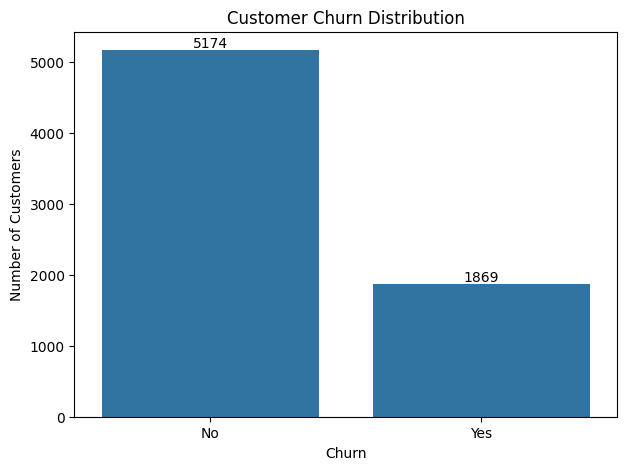

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

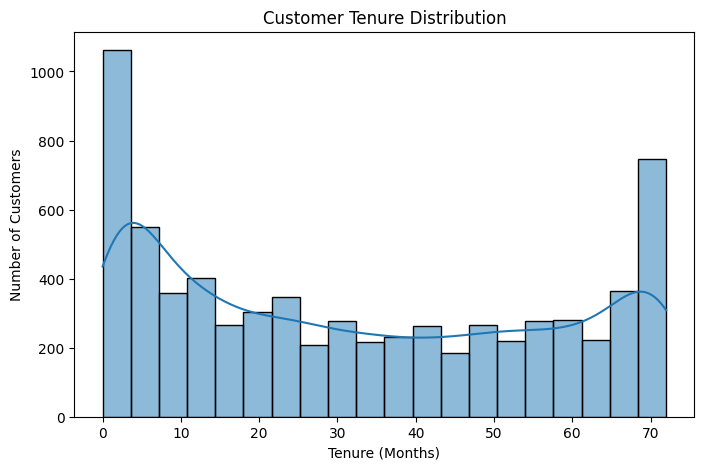

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='tenure', bins=20, kde=True)

plt.title('Customer Tenure Distribution')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')

plt.show()

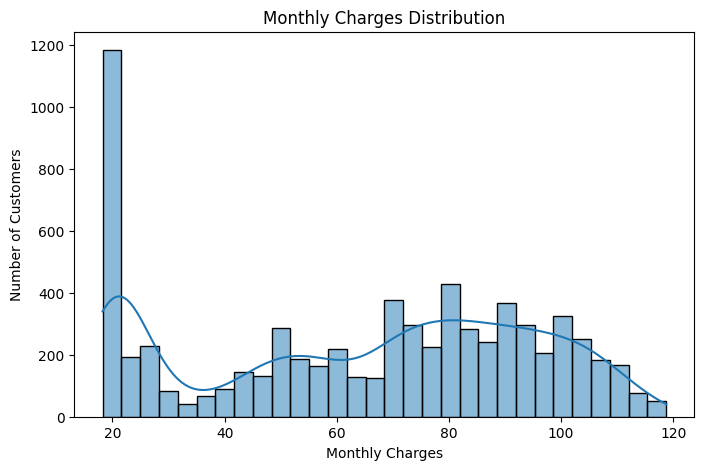

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='MonthlyCharges', bins=30, kde=True)

plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')

plt.show()

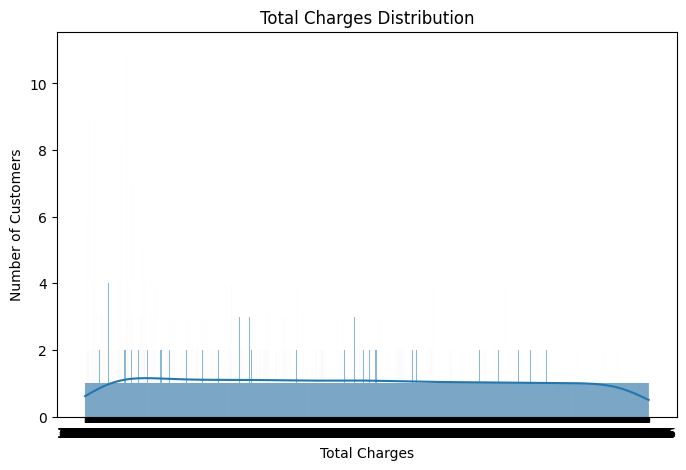

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='TotalCharges', bins=30, kde=True)

plt.title('Total Charges Distribution')
plt.xlabel('Total Charges')
plt.ylabel('Number of Customers')

plt.show()

In [21]:
# Check the data type of TotalCharges
print("Data type of TotalCharges:", df['TotalCharges'].dtype)

# Find values that cannot be converted to numbers
total_charges_numeric = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

invalid_total_charges = total_charges_numeric.isna().sum()

print("Values that cannot be converted to numeric:", invalid_total_charges)

Data type of TotalCharges: object
Values that cannot be converted to numeric: 11


In [22]:
# Convert TotalCharges temporarily to numeric
total_charges_numeric = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

# Display rows where conversion failed
invalid_rows = df[total_charges_numeric.isna()]

print("Number of invalid TotalCharges records:", len(invalid_rows))

display(
    invalid_rows[
        ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
    ]
)

Number of invalid TotalCharges records: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.5500,,No
753,3115-CZMZD,0,20.2500,,No
936,5709-LVOEQ,0,80.8500,,No
1082,4367-NUYAO,0,25.7500,,No
1340,1371-DWPAZ,0,56.0500,,No
3331,7644-OMVMY,0,19.8500,,No
3826,3213-VVOLG,0,25.3500,,No
4380,2520-SGTTA,0,20.0000,,No
5218,2923-ARZLG,0,19.7000,,No
6670,4075-WKNIU,0,73.3500,,No


In [23]:
# Convert TotalCharges to numeric for EDA
total_charges_eda = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

print("TotalCharges numeric values:", total_charges_eda.notna().sum())
print("TotalCharges invalid/missing after conversion:", total_charges_eda.isna().sum())

TotalCharges numeric values: 7032
TotalCharges invalid/missing after conversion: 11


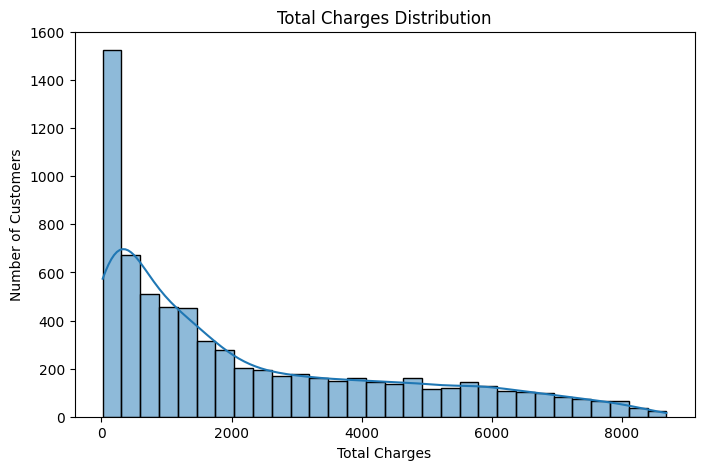

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(
    total_charges_eda.dropna(),
    bins=30,
    kde=True
)

plt.title('Total Charges Distribution')
plt.xlabel('Total Charges')
plt.ylabel('Number of Customers')

plt.show()

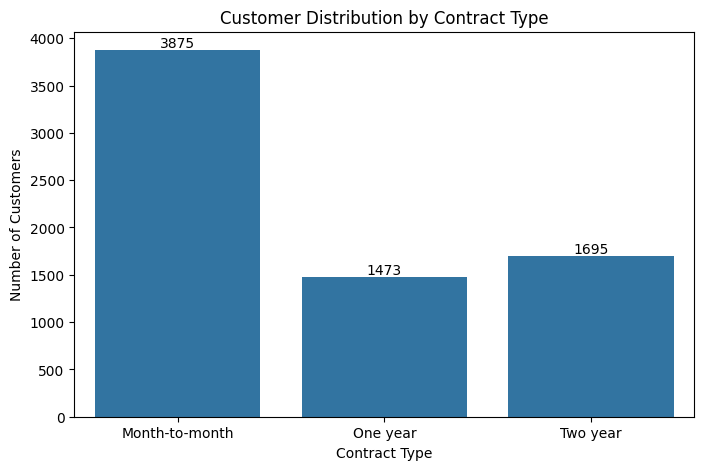

In [25]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x='Contract')

plt.title('Customer Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=0)
plt.show()

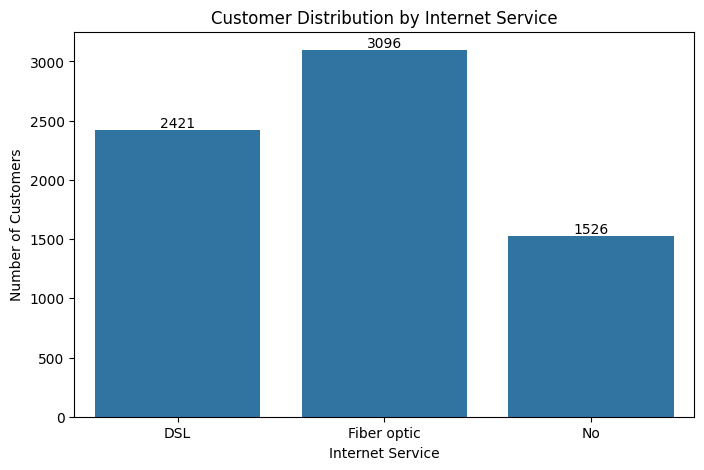

In [26]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x='InternetService')

plt.title('Customer Distribution by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

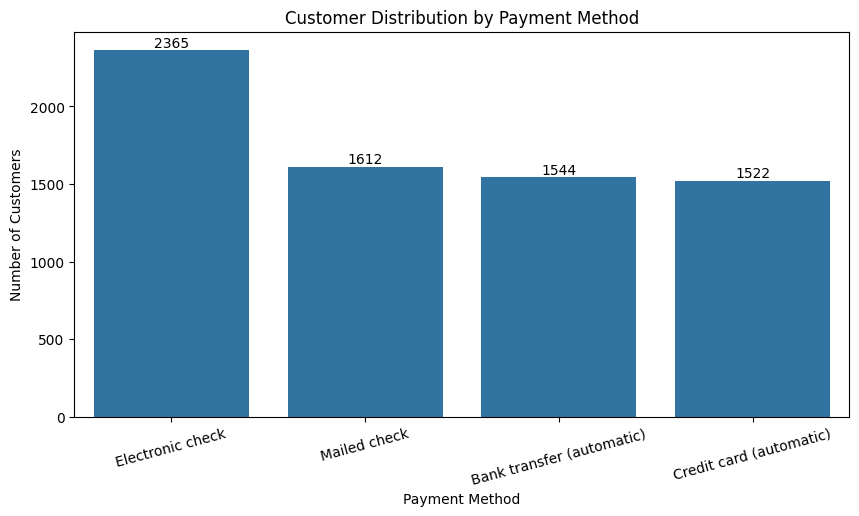

In [27]:
plt.figure(figsize=(10, 5))

ax = sns.countplot(data=df, x='PaymentMethod')

plt.title('Customer Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=15)
plt.show()

In [28]:
# Churn rate by contract type

contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

print("Churn percentage by contract type:")
print(contract_churn.round(2))

Churn percentage by contract type:
Churn               No     Yes
Contract                      
Month-to-month 57.2900 42.7100
One year       88.7300 11.2700
Two year       97.1700  2.8300


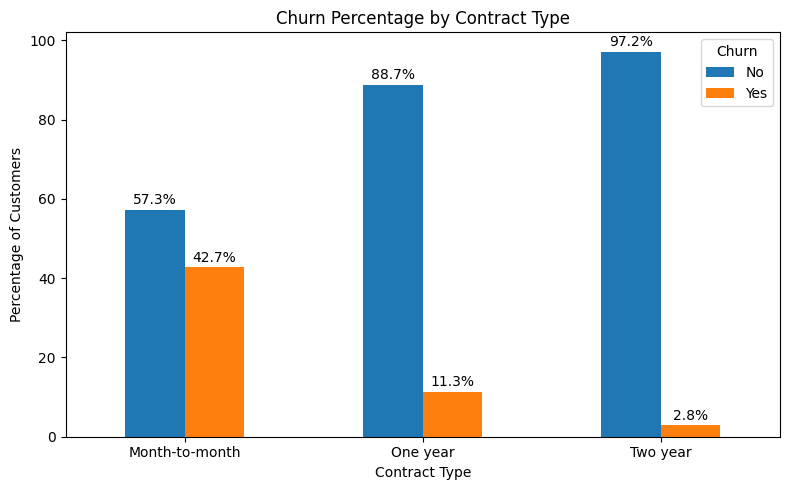

In [30]:
# Create churn percentage data
contract_churn_plot = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

# Plot churn percentage
ax = contract_churn_plot[['No', 'Yes']].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Churn Percentage by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2)

plt.tight_layout()
plt.show()

In [31]:
# Churn percentage by Internet Service

internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

print("Churn percentage by Internet Service:")
print(internet_churn.round(2))

Churn percentage by Internet Service:
Churn                No     Yes
InternetService                
DSL             81.0400 18.9600
Fiber optic     58.1100 41.8900
No              92.6000  7.4000


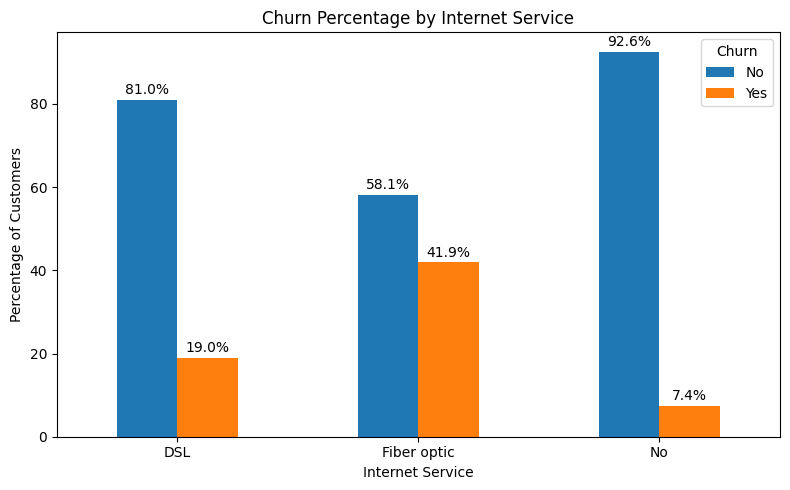

In [32]:
# Plot churn percentage by Internet Service

ax = internet_churn[['No', 'Yes']].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Churn Percentage by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2)

plt.tight_layout()
plt.show()

In [33]:
# Churn percentage by Payment Method

payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

print("Churn percentage by Payment Method:")
print(payment_churn.round(2))

Churn percentage by Payment Method:
Churn                          No     Yes
PaymentMethod                            
Bank transfer (automatic) 83.2900 16.7100
Credit card (automatic)   84.7600 15.2400
Electronic check          54.7100 45.2900
Mailed check              80.8900 19.1100


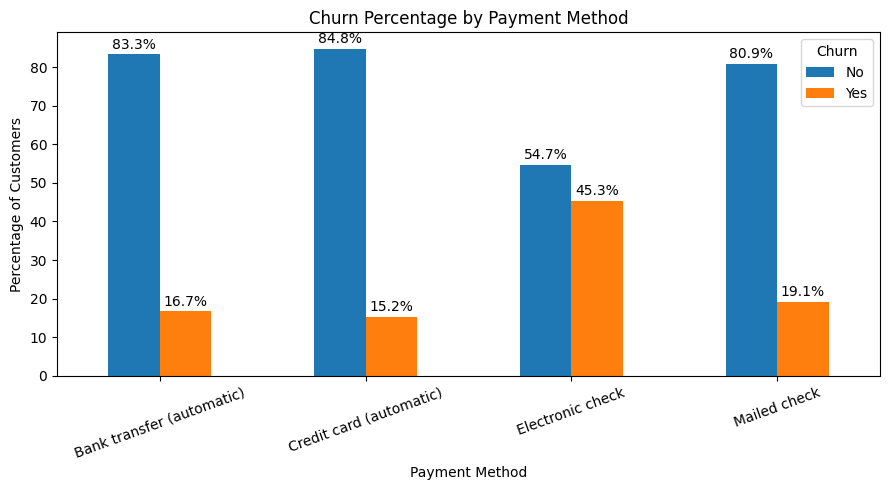

In [34]:
# Plot churn percentage by Payment Method

ax = payment_churn[['No', 'Yes']].plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Churn Percentage by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=20)
plt.legend(title='Churn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1060/1218689199.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn')


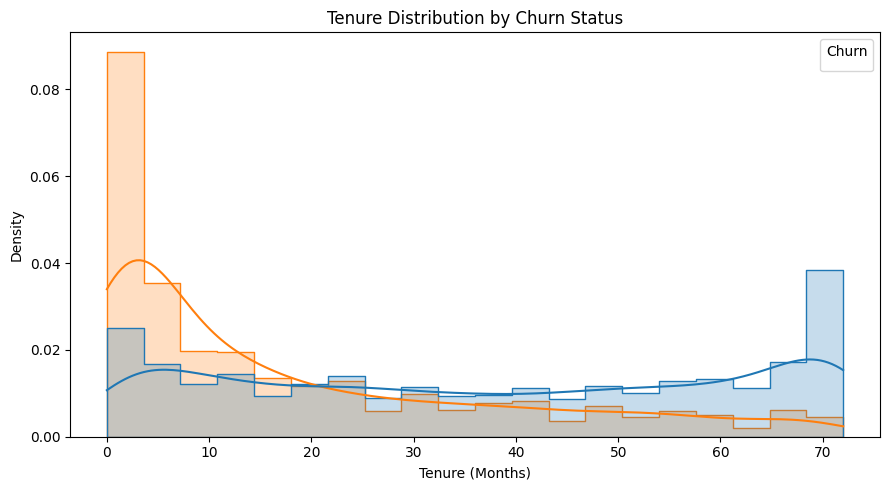

In [35]:
# Tenure distribution by churn status

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    bins=20,
    kde=True,
    element='step',
    stat='density',
    common_norm=False
)

plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Density')
plt.legend(title='Churn')

plt.tight_layout()
plt.show()

In [36]:
# Compare tenure statistics by churn status

tenure_churn_stats = df.groupby('Churn')['tenure'].describe()

print("Tenure statistics by churn status:")
print(tenure_churn_stats.round(2))

Tenure statistics by churn status:
          count    mean     std    min     25%     50%     75%     max
Churn                                                                 
No    5174.0000 37.5700 24.1100 0.0000 15.0000 38.0000 61.0000 72.0000
Yes   1869.0000 17.9800 19.5300 1.0000  2.0000 10.0000 29.0000 72.0000


In [37]:
print("Mean tenure by churn status:")
print(df.groupby('Churn')['tenure'].mean().round(2))

print("\nMedian tenure by churn status:")
print(df.groupby('Churn')['tenure'].median())

Mean tenure by churn status:
Churn
No    37.5700
Yes   17.9800
Name: tenure, dtype: float64

Median tenure by churn status:
Churn
No    38.0000
Yes   10.0000
Name: tenure, dtype: float64


In [38]:
monthly_charges_churn = df.groupby('Churn')['MonthlyCharges'].describe()

print("Monthly charges statistics by churn status:")
print(monthly_charges_churn.round(2))

Monthly charges statistics by churn status:
          count    mean     std     min     25%     50%     75%      max
Churn                                                                   
No    5174.0000 61.2700 31.0900 18.2500 25.1000 64.4300 88.4000 118.7500
Yes   1869.0000 74.4400 24.6700 18.8500 56.1500 79.6500 94.2000 118.3500


In [39]:
print("Mean monthly charges by churn status:")
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

print("\nMedian monthly charges by churn status:")
print(df.groupby('Churn')['MonthlyCharges'].median().round(2))

Mean monthly charges by churn status:
Churn
No    61.2700
Yes   74.4400
Name: MonthlyCharges, dtype: float64

Median monthly charges by churn status:
Churn
No    64.4300
Yes   79.6500
Name: MonthlyCharges, dtype: float64


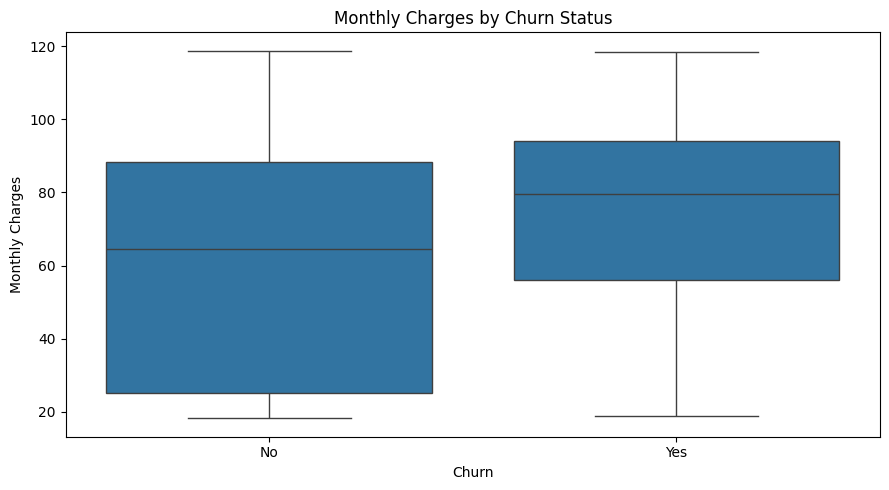

In [40]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.tight_layout()
plt.show()

In [42]:
# Create a separate dataframe for correlation analysis
df_corr = df.copy()

# Convert TotalCharges to numeric
# Invalid/blank values will become NaN
df_corr['TotalCharges'] = pd.to_numeric(
    df_corr['TotalCharges'],
    errors='coerce'
)

# Convert Churn into numeric format
df_corr['Churn_Numeric'] = df_corr['Churn'].map({
    'No': 0,
    'Yes': 1
})

# Select numerical features
numeric_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Churn_Numeric'
]

# Calculate correlation
correlation_matrix = df_corr[numeric_features].corr()

print("Correlation Matrix:")
print(correlation_matrix.round(3))

Correlation Matrix:
                tenure  MonthlyCharges  TotalCharges  Churn_Numeric
tenure          1.0000          0.2480        0.8260        -0.3520
MonthlyCharges  0.2480          1.0000        0.6510         0.1930
TotalCharges    0.8260          0.6510        1.0000        -0.1990
Churn_Numeric  -0.3520          0.1930       -0.1990         1.0000


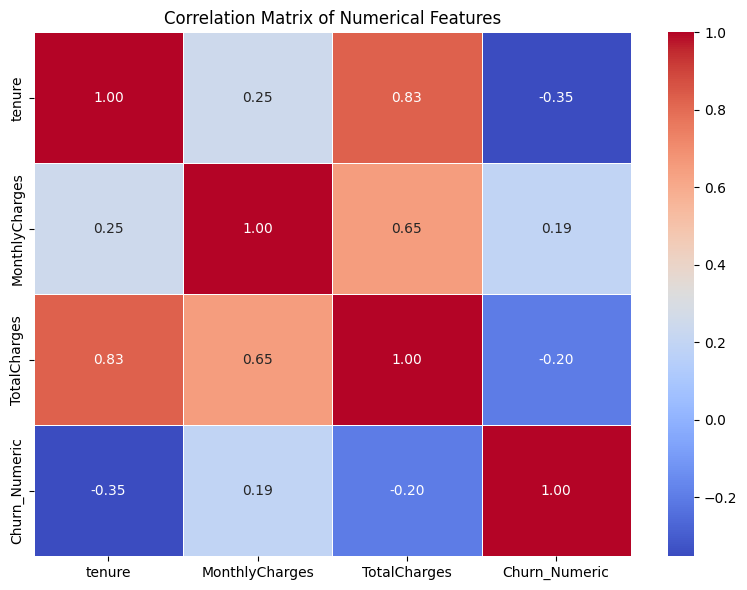

In [43]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [44]:
print("Correlation of numerical features with Churn:")

churn_correlations = (
    correlation_matrix['Churn_Numeric']
    .drop('Churn_Numeric')
    .sort_values(ascending=False)
)

print(churn_correlations.round(3))

Correlation of numerical features with Churn:
MonthlyCharges    0.1930
TotalCharges     -0.1990
tenure           -0.3520
Name: Churn_Numeric, dtype: float64


In [45]:
# Outlier analysis using the IQR method

outlier_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("Outlier Analysis using IQR Method")
print("-" * 50)

for column in outlier_columns:
    Q1 = df_corr[column].quantile(0.25)
    Q3 = df_corr[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_corr[
        (df_corr[column] < lower_bound) |
        (df_corr[column] > upper_bound)
    ][column].dropna()

    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / df_corr[column].notna().sum()) * 100

    print(f"\nFeature: {column}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of Outliers: {outlier_count}")
    print(f"Outlier Percentage: {outlier_percentage:.2f}%")

Outlier Analysis using IQR Method
--------------------------------------------------

Feature: tenure
Q1: 9.00
Q3: 55.00
IQR: 46.00
Lower Bound: -60.00
Upper Bound: 124.00
Number of Outliers: 0
Outlier Percentage: 0.00%

Feature: MonthlyCharges
Q1: 35.50
Q3: 89.85
IQR: 54.35
Lower Bound: -46.02
Upper Bound: 171.38
Number of Outliers: 0
Outlier Percentage: 0.00%

Feature: TotalCharges
Q1: 401.45
Q3: 3794.74
IQR: 3393.29
Lower Bound: -4688.48
Upper Bound: 8884.67
Number of Outliers: 0
Outlier Percentage: 0.00%


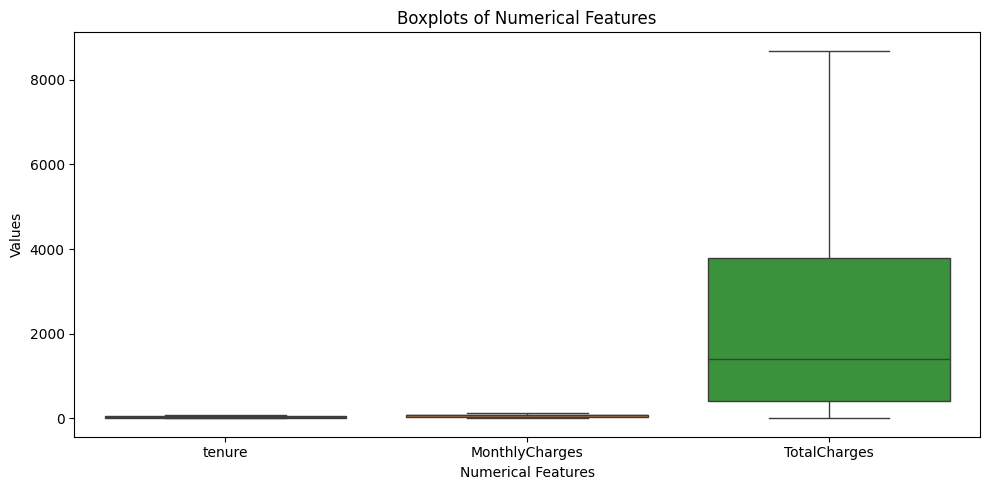

In [46]:
# Boxplots for numerical features

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_corr[['tenure', 'MonthlyCharges', 'TotalCharges']]
)

plt.title('Boxplots of Numerical Features')
plt.xlabel('Numerical Features')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

In [47]:
# Calculate churn rates for important categorical features

categorical_features = [
    'Contract',
    'InternetService',
    'PaymentMethod'
]

for feature in categorical_features:
    churn_rate = pd.crosstab(
        df[feature],
        df['Churn'],
        normalize='index'
    ) * 100

    print(f"\nChurn Rate by {feature}:")
    print(churn_rate.round(2))


Churn Rate by Contract:
Churn               No     Yes
Contract                      
Month-to-month 57.2900 42.7100
One year       88.7300 11.2700
Two year       97.1700  2.8300

Churn Rate by InternetService:
Churn                No     Yes
InternetService                
DSL             81.0400 18.9600
Fiber optic     58.1100 41.8900
No              92.6000  7.4000

Churn Rate by PaymentMethod:
Churn                          No     Yes
PaymentMethod                            
Bank transfer (automatic) 83.2900 16.7100
Credit card (automatic)   84.7600 15.2400
Electronic check          54.7100 45.2900
Mailed check              80.8900 19.1100
